# Default Random Forest Classifier

Baseline notebook for training a `RandomForestClassifier` on `Tommy_Award_Player_Game_Table_hustle.csv` using the same setup as your decision tree notebook.

In [1]:

from pathlib import Path
import random

import numpy as np
import pandas as pd

SEED = 58
random.seed(SEED)
np.random.seed(SEED)

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {csv_path.name}")
df.head()

Loaded 8,530 rows and 60 columns from Tommy_Award_Player_Game_Table_hustle.csv


,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [2]:
target_col = "y"
numeric_feature_cols = [
    "minutes_decimal",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "net_rating",
    "usage_rate",
    "impact_efficiency",
    "role_outperformance",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "threePointersMade",
    "threePointersAttempted",
    "freeThrowsMade",
    "stocks",
    "points_per_min",
    "oreb_per_min",
    "reb_per_min",
    "ast_per_min",
    "stocks_per_min",
    "hustle_proxy",
    "points_rank",
    "reboundsOffensive_rank",
    "reboundsTotal_rank",
    "assists_rank",
    "steals_rank",
    "blocks_rank",
    "plusMinusPoints_rank",
    "minutes_decimal_rank",
    "stocks_rank",
    "hustle_proxy_rank",
]

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

if "GAME_ID" in df.columns:
    game_id_col = "GAME_ID"
elif "gameId" in df.columns:
    game_id_col = "gameId"
else:
    raise ValueError("Could not find game id column (expected GAME_ID or gameId).")

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce", format="mixed")

if "season" not in df.columns:
    if "game_date" not in df.columns:
        raise ValueError("Need either 'season' or 'game_date' to derive seasons.")
    start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
    df["season"] = start_year.astype("Int64").astype(str) + "-" + (start_year + 1).astype("Int64").astype(str).str[-2:]

# Match the ridge/lasso and decision tree notebooks: only rows where a player logged minutes.
df = df[df["minutes_decimal"] > 0].copy()
mins = df["minutes_decimal"].clip(lower=1e-6)

# Recreate derived columns used by the shared feature list when missing.
if "net_rating" not in df.columns:
    df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

if "stocks_per_min" not in df.columns:
    df["stocks_per_min"] = pd.to_numeric(df["stocks"], errors="coerce") / mins

eps = 1e-6
if "impact_efficiency" not in df.columns:
    df["impact_efficiency"] = pd.to_numeric(df["net_rating"], errors="coerce") / (pd.to_numeric(df["usage_rate"], errors="coerce") + eps)

if "role_outperformance" not in df.columns:
    df["role_outperformance"] = pd.to_numeric(df["net_rating"], errors="coerce") * (1 - pd.to_numeric(df["usage_rate"], errors="coerce"))

if "stocks_rank" not in df.columns:
    df["stocks_rank"] = df.groupby(game_id_col)["stocks"].rank(method="min", ascending=False)

if "hustle_proxy_rank" not in df.columns:
    df["hustle_proxy_rank"] = df.groupby(game_id_col)["hustle_proxy"].rank(method="min", ascending=False)

missing_cols = [col for col in numeric_feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

X = df[numeric_feature_cols].copy()
y = df[target_col].astype(int)

print(f"Rows after minutes filter: {len(df):,}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Target vector shape: {y.shape}")

Rows after minutes filter: 8,495
Numeric features: 39
Target vector shape: (8495,)


In [3]:
requested_test_seasons = ["2024-25", "2025-26"]
available_seasons = sorted(df["season"].dropna().astype(str).unique().tolist())
selected_test_seasons = [s for s in requested_test_seasons if s in available_seasons]

if not selected_test_seasons:
    raise ValueError(
        f"None of the requested test seasons were found. Requested={requested_test_seasons}, available={available_seasons}"
    )

train_df = df[~df["season"].isin(selected_test_seasons)].copy()
test_df = df[df["season"].isin(selected_test_seasons)].copy()

X_train = train_df[numeric_feature_cols].copy()
X_test = test_df[numeric_feature_cols].copy()
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

train_seasons_for_val = sorted(
    train_df["season"].dropna().astype(str).unique().tolist(),
    key=lambda s: int(s.split("-")[0]),
)
validation_season = train_seasons_for_val[-1] if train_seasons_for_val else "n/a"
validation_games = (
    train_df.loc[train_df["season"] == validation_season, game_id_col].nunique()
    if validation_season != "n/a"
    else 0
)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "validation_season",
            "validation_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_feature_cols),
            0,
            train_df[game_id_col].nunique(),
            validation_season,
            validation_games,
            test_df[game_id_col].nunique(),
            round(train_df[target_col].mean(), 4),
            ", ".join(selected_test_seasons),
            "random_forest_optuna_tuned",
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,train_games,626
4,validation_season,2023-24
5,validation_games,79
6,test_games,163
7,train_positive_rate,0.0927
8,test_seasons,"2024-25, 2025-26"
9,models,random_forest_optuna_tuned


In [4]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)

OPTUNA_TRIALS = 25
OPTUNA_TIMEOUT_SECONDS = 300
RANDOM_STATE = SEED


def sort_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda s: int(str(s).split("-")[0]))


def score_game_top1(scored: pd.DataFrame) -> float:
    winner_idx_local = scored.groupby(game_id_col)["pred_prob"].idxmax()
    score = float(scored.loc[winner_idx_local, target_col].mean())
    return 0.0 if pd.isna(score) else score


def score_game_topk(scored: pd.DataFrame, k: int) -> float:
    """Fraction of games where the true winner (y=1) is among the top-k rows by pred_prob."""

    def _game_hit(group: pd.DataFrame) -> bool:
        top = group.nlargest(k, "pred_prob")
        return bool((top[target_col] == 1).any())

    hits = scored.groupby(game_id_col, group_keys=False).apply(_game_hit)
    return float(hits.mean())


# Temporal validation split inside training data:
# - inner train: earlier seasons
# - val: latest season in train_df
train_seasons = sort_seasons(train_df["season"].dropna().astype(str).unique().tolist())
if len(train_seasons) < 2:
    raise ValueError("Need at least 2 train seasons for Optuna temporal validation.")

val_season = train_seasons[-1]
inner_train_df = train_df[train_df["season"].isin(train_seasons[:-1])].copy()
val_df = train_df[train_df["season"] == val_season].copy()

X_inner_train = inner_train_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())
y_inner_train = inner_train_df[target_col].astype(int)
X_val = val_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())


def objective(trial: optuna.trial.Trial) -> float:
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0) if bootstrap else None

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": bootstrap,
        "max_samples": max_samples,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    try:
        candidate = RandomForestClassifier(**params)
        candidate.fit(X_inner_train, y_inner_train)

        val_scored = val_df.copy()
        val_scored["pred_prob"] = candidate.predict_proba(X_val)[:, 1]
        return score_game_top1(val_scored)
    except ValueError:
        return 0.0


sampler = TPESampler(seed=RANDOM_STATE)
pruner = MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    gc_after_trial=True,
    show_progress_bar=True,
)

best_rf_params = {
    **study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Ensure max_samples is explicit when bootstrap=False.
if not best_rf_params.get("bootstrap", True):
    best_rf_params["max_samples"] = None

model = RandomForestClassifier(**best_rf_params)
model.fit(X_train.fillna(X_train.median()), y_train)

# Validation metrics: evaluate best params on the held-out validation season.
best_val_model = RandomForestClassifier(**best_rf_params)
best_val_model.fit(X_inner_train, y_inner_train)

val_scored = val_df.copy()
val_scored["pred_prob"] = best_val_model.predict_proba(X_val)[:, 1]
val_winner_idx = val_scored.groupby(game_id_col)["pred_prob"].idxmax()
y_val_top1 = pd.Series(0, index=val_scored.index, dtype=int)
y_val_top1.loc[val_winner_idx] = 1
y_val_true = val_df[target_col].astype(int)

val_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": val_scored.loc[val_winner_idx, target_col].mean(),
            "game_top3_accuracy": score_game_topk(val_scored, 3),
            "row_f1": f1_score(y_val_true, y_val_top1, zero_division=0),
            "row_recall": recall_score(y_val_true, y_val_top1, zero_division=0),
            "row_prauc": average_precision_score(y_val_true, val_scored["pred_prob"]),
            "row_logloss": log_loss(y_val_true, val_scored["pred_prob"], labels=[0, 1]),
            "row_brier": brier_score_loss(y_val_true, val_scored["pred_prob"]),
            "row_precision": precision_score(y_val_true, y_val_top1, zero_division=0),
        }
    ]
)

# Test metrics: score rows and convert probabilities to one predicted winner per game (top-1).
scored_df = test_df.copy()
scored_df["pred_prob"] = model.predict_proba(X_test.fillna(X_train.median()))[:, 1]
winner_idx = scored_df.groupby(game_id_col)["pred_prob"].idxmax()
y_pred_top1 = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1.loc[winner_idx] = 1

test_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": scored_df.loc[winner_idx, target_col].mean(),
            "game_top3_accuracy": score_game_topk(scored_df, 3),
            "row_f1": f1_score(y_test, y_pred_top1, zero_division=0),
            "row_recall": recall_score(y_test, y_pred_top1, zero_division=0),
            "row_prauc": average_precision_score(y_test, scored_df["pred_prob"]),
            "row_logloss": log_loss(y_test, scored_df["pred_prob"], labels=[0, 1]),
            "row_brier": brier_score_loss(y_test, scored_df["pred_prob"]),
            "row_precision": precision_score(y_test, y_pred_top1, zero_division=0),
        }
    ]
)

feature_importance_df = (
    pd.DataFrame({"feature": numeric_feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Best Optuna validation game_top1_accuracy ({val_season}): {study.best_value:.4f}")
print("Best random forest hyperparameters:")
display(pd.DataFrame([best_rf_params]))

print(f"Validation metrics ({val_season}):")
display(val_metrics_df)

print("Random forest metrics on test seasons:")
display(test_metrics_df)

print("Top 15 feature importances:")
display(feature_importance_df.head(15))

[I 2026-04-27 19:38:08,875] A new study created in memory with name: no-name-b7e50944-90f8-4bd5-aea8-847dfb618745


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-27 19:38:15,904] Trial 0 finished with value: 0.3291139240506329 and parameters: {'bootstrap': False, 'n_estimators': 324, 'max_depth': 5, 'min_samples_split': 47, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.3291139240506329.
[I 2026-04-27 19:38:16,971] Trial 1 finished with value: 0.34177215189873417 and parameters: {'bootstrap': True, 'max_samples': 0.6903409135765872, 'n_estimators': 207, 'max_depth': 13, 'min_samples_split': 63, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-27 19:38:18,931] Trial 2 finished with value: 0.31645569620253167 and parameters: {'bootstrap': True, 'max_samples': 0.6394433973039604, 'n_estimators': 351, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.34177215189873417.
[I 2026-04-27 19:38:25,973] Trial 3 finished with value: 0.2911392405063291 and parameters: {'bootstrap': False, 'n

/var/folders/bb/g3jnl_p57d11fvwjyxpcpwhc0000gn/T/ipykernel_16429/1052320410.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hits = scored.groupby(game_id_col, group_keys=False).apply(_game_hit)


Best Optuna validation game_top1_accuracy (2023-24): 0.3797
Best random forest hyperparameters:


...

,game_top1_accuracy,game_top3_accuracy,row_f1,row_recall,row_prauc,row_logloss,row_brier,row_precision
0,0.379747,0.78481,0.379747,0.379747,0.343823,0.249992,0.074226,0.379747


Random forest metrics on test seasons:


,game_top1_accuracy,game_top3_accuracy,row_f1,row_recall,row_prauc,row_logloss,row_brier,row_precision
0,0.423313,0.785276,0.423313,0.423313,0.362962,0.233886,0.07088,0.423313


Top 15 feature importances:


,feature,importance
0,points_per_min,0.087298
1,points,0.075016
2,fieldGoalsMade,0.069217
3,points_rank,0.059923
4,usage_rate,0.045435
5,fieldGoalsAttempted,0.043406
6,minutes_decimal,0.039142
7,reb_per_min,0.034920
8,threePointersMade,0.034456
9,impact_efficiency,0.033845


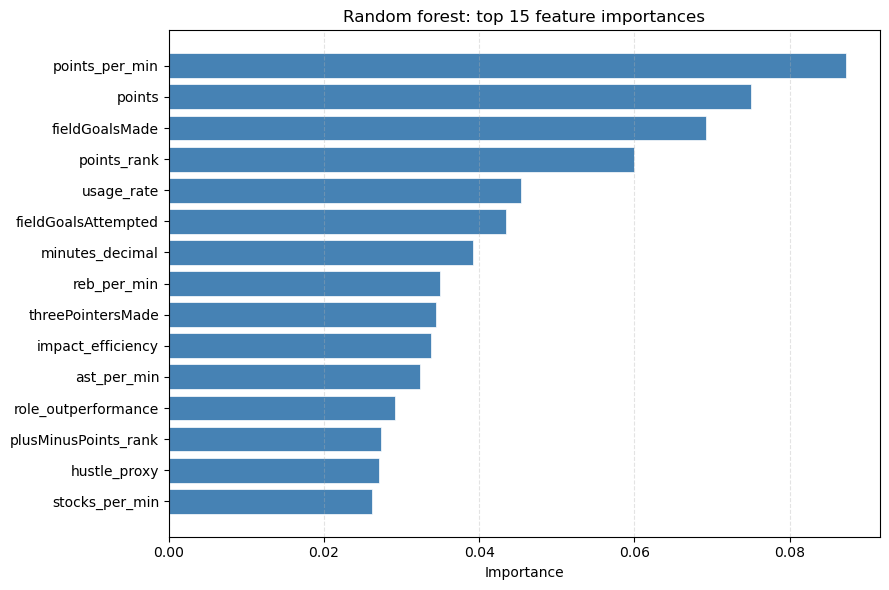

In [6]:
import matplotlib.pyplot as plt

fi_top = feature_importance_df.head(15).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_top["feature"], fi_top["importance"], color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance")
ax.set_title("Random forest: top 15 feature importances")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

Confusion Matrix (Top-1 per game):
[[1482   94]
 [  94   69]]


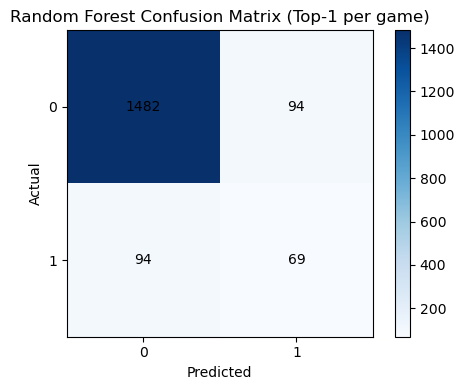

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Evaluate with the same top-1-per-game prediction logic used in metrics_df.
y_pred_top1_for_cm = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1_for_cm.loc[winner_idx] = 1

print("Confusion Matrix (Top-1 per game):")
cm = confusion_matrix(y_test, y_pred_top1_for_cm)
print(cm)

try:
    import seaborn as sns

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("Random Forest Confusion Matrix (Top-1 per game)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
except ModuleNotFoundError:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Random Forest Confusion Matrix (Top-1 per game)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

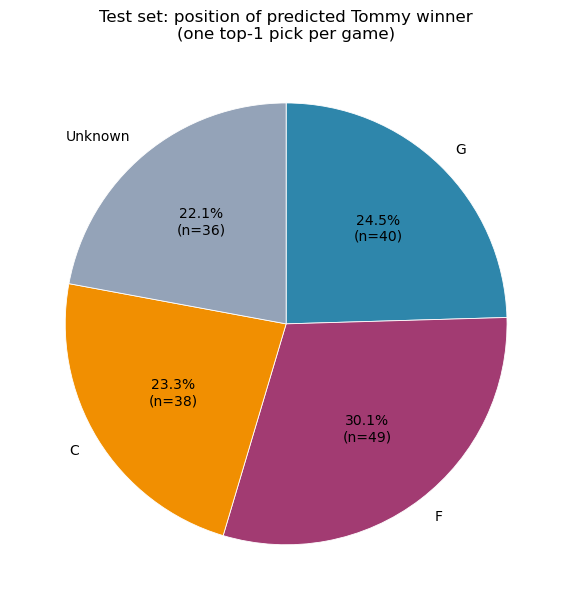

Counts: {'F': 49, 'G': 40, 'C': 38, 'Unknown': 36}


In [5]:
# Pie chart: position of the model's predicted winner (top-1 per test game)
import matplotlib.pyplot as plt
import numpy as np

if "winner_idx" not in globals() or "scored_df" not in globals():
    raise RuntimeError("Run the Optuna / training cell first (needs scored_df, winner_idx).")

_pred = scored_df.loc[winner_idx]
_pos = _pred["position"].fillna("Unknown")
_counts = _pos.value_counts()
_order = [x for x in ("G", "F", "C", "Unknown") if x in _counts.index]
_extra = [x for x in _counts.index if x not in _order]
labels = _order + _extra
sizes = np.array([_counts[x] for x in labels], dtype=float)
colors = {"G": "#2E86AB", "F": "#A23B72", "C": "#F18F01", "Unknown": "#94A3B8"}
color_list = [colors.get(lb, "#64748B") for lb in labels]

def _autopct(values):
    def _inner(pct: float) -> str:
        n = int(round(pct / 100.0 * values.sum()))
        return f"{pct:.1f}%\n(n={n})"

    return _inner

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.pie(
    sizes,
    labels=labels,
    colors=color_list,
    startangle=90,
    counterclock=False,
    autopct=_autopct(sizes),
    wedgeprops={"edgecolor": "white", "linewidth": 0.6},
)
ax.set_title("Test set: position of predicted Tommy winner\n(one top-1 pick per game)")
plt.tight_layout()
plt.show()

print("Counts:", _counts.to_dict())

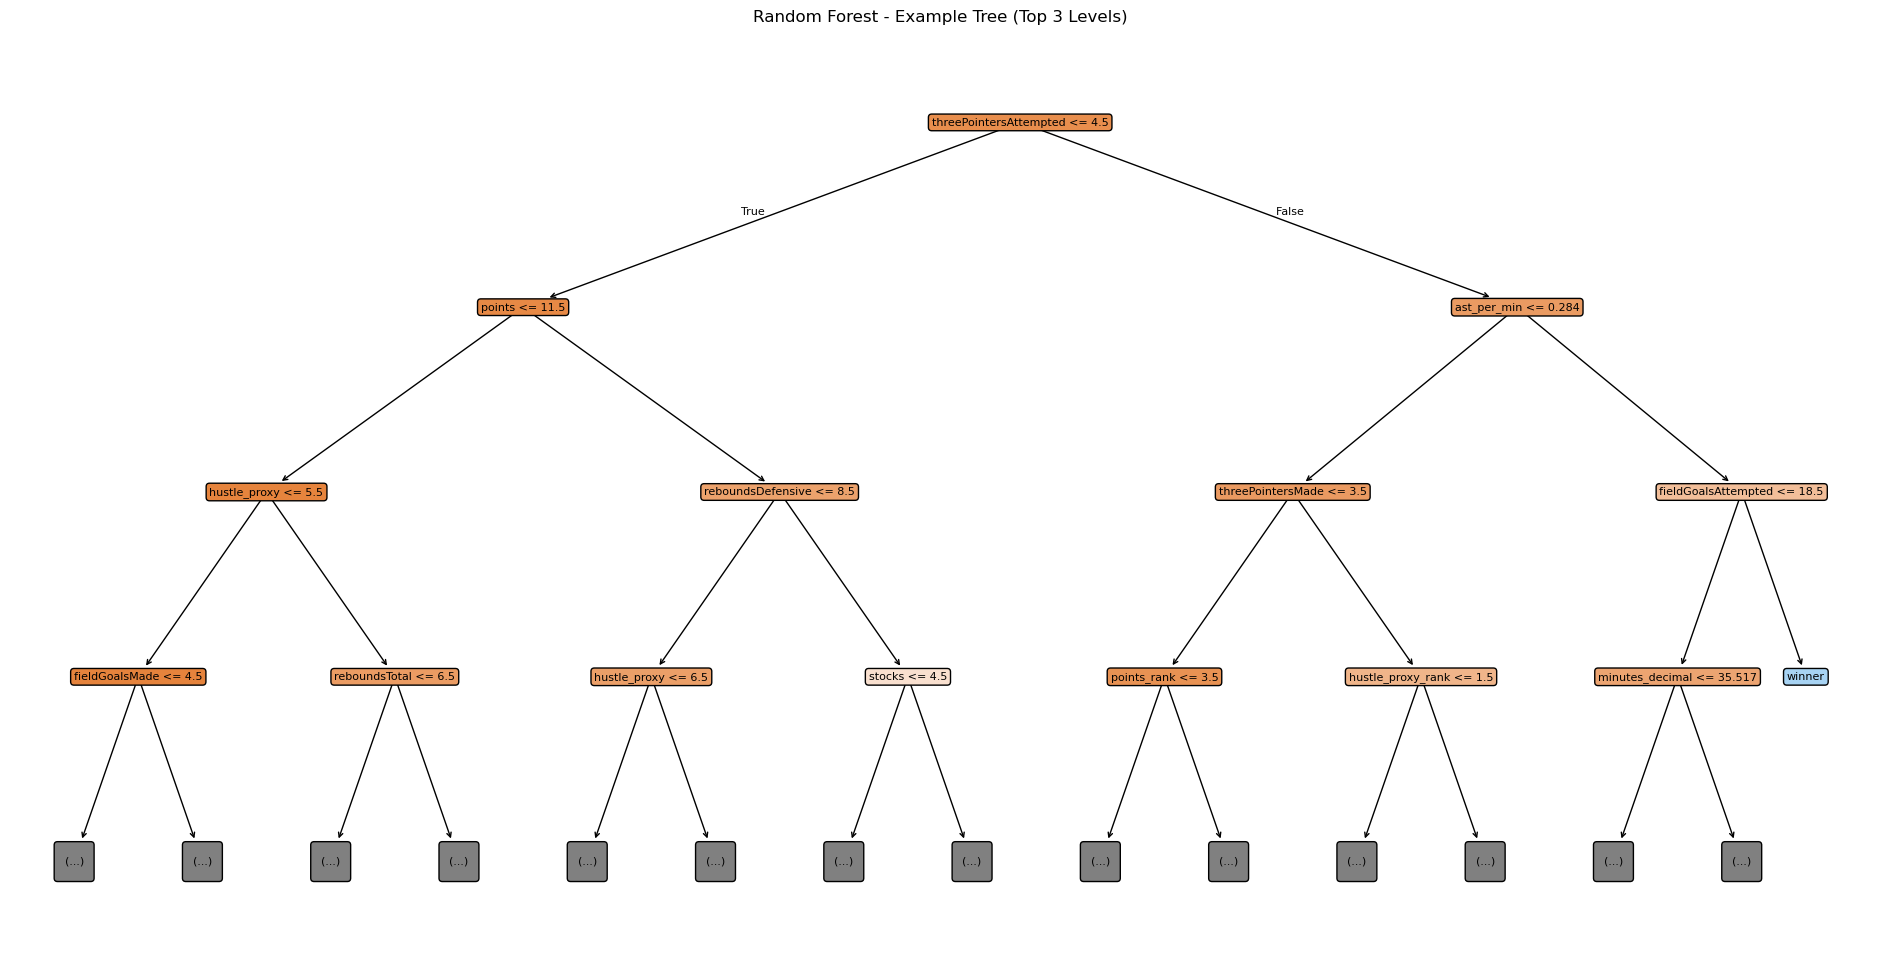

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import _export, _tree


# sklearn.plot_tree always prints samples + value; use a small exporter so each box
# is only: split (feature & threshold) or predicted class.
class _SplitAndClassMPLTreeExporter(_export._MPLTreeExporter):
    def node_to_str(self, tree, node_id, criterion):
        if tree.n_outputs == 1:
            value = tree.value[node_id][0, :]
        else:
            value = tree.value[node_id]
        ch = self.characters
        if tree.children_left[node_id] != _tree.TREE_LEAF:
            if self.feature_names is not None:
                feature = self.str_escape(self.feature_names[tree.feature[node_id]])
            else:
                feature = "x%s%s%s" % (ch[1], tree.feature[node_id], ch[2])
            thr = round(tree.threshold[node_id], self.precision)
            node_string = f"{feature} {ch[3]} {thr}{ch[4]}"
        elif (
            self.class_names is not None
            and tree.n_classes[0] != 1
            and tree.n_outputs == 1
        ):
            if self.class_names is not True:
                cname = self.str_escape(self.class_names[int(np.argmax(value))])
            else:
                cname = "y%s%s%s" % (ch[1], int(np.argmax(value)), ch[2])
            node_string = cname
        else:
            return super().node_to_str(tree, node_id, criterion)
        if node_string.endswith(ch[4]):
            node_string = node_string[: -len(ch[4])]
        return node_string + ch[5]


# Visualize one tree from the random forest (first estimator).
# Limiting depth keeps the plot readable.
one_tree = model.estimators_[0]

fig, ax = plt.subplots(figsize=(24, 12))
exporter = _SplitAndClassMPLTreeExporter(
    max_depth=3,
    feature_names=numeric_feature_cols,
    class_names=["not_winner", "winner"],
    label="all",
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,
    proportion=False,
    precision=3,
)
exporter.export(one_tree, ax=ax)
plt.title("Random Forest - Example Tree (Top 3 Levels)")
plt.show()

### Obscure correct winners (table games only)

**Eight test games (2024–25 & 2025–26)** from the “most obscure correct Tommy winners” table (Queta, Garza, Minott, Kornet with deep `minutes_decimal_rank`). Not the broader top-20 heuristics—only these `gameId`s. Run after the training/metrics cell so `scored_df` and `winner_idx` exist.


In [8]:
# Model's top-1 pick per test game; keep only the eight games from the obscure-correct table.
pred_winners = scored_df.loc[winner_idx].copy()

# Fixed test-set gameIds (N. Queta, L. Garza, J. Minott, L. Kornet; bench-depth summary table).
OBSCURE_TABLE_GAME_IDS = {
    22400073,  # N. Queta, 9th in min, ~0.31
    22400281,  # N. Queta, 6th, ~0.44
    22401106,  # L. Kornet, 6th, ~0.32
    22500193,  # L. Garza, 8th, ~0.38
    22500999,  # L. Garza, 8th, ~0.38
    22500277,  # J. Minott, 7th, ~0.48
    22500293,  # N. Queta, 5th, ~0.61
    22500874,  # N. Queta, 6th, ~0.71
}
missing_ids = OBSCURE_TABLE_GAME_IDS - set(pred_winners[game_id_col].astype(int))
if missing_ids:
    raise ValueError(
        f"These gameIds are not in the current test `pred_winners` (re-run split/model?): {sorted(missing_ids)}"
    )

obscure = pred_winners[pred_winners[game_id_col].astype(int).isin(OBSCURE_TABLE_GAME_IDS)].copy()

stat_cols = [
    game_id_col,
    "season",
    "game_date",
    "teamTricode",
    "nameI",
    "firstName",
    "familyName",
    "position",
    "minutes",
    "minutes_decimal",
    "minutes_decimal_rank",
    "points",
    "points_rank",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "reboundsTotal_rank",
    "assists",
    "assists_rank",
    "steals",
    "steals_rank",
    "blocks",
    "blocks_rank",
    "stocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "plusMinusPoints_rank",
    "hustle_proxy",
    "hustle_proxy_rank",
    "usage_rate",
    "y",
    "pred_prob",
]
stat_cols = [c for c in stat_cols if c in obscure.columns]

# Sorted by season then game
sort_keys = [c for c in ("season", game_id_col) if c in obscure.columns]
obscure_st = obscure[stat_cols].sort_values(sort_keys, kind="mergesort")

print(f"Unique games in this table: {obscure_st[game_id_col].nunique()}")
print(f"Rows (model-predicted winner rows): {len(obscure_st)}")
print()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)
display(obscure_st)

# Plain list of game ids for copy-paste / filtering elsewhere
print("\n gameId list (unique, sorted):")
print(sorted(obscure_st[game_id_col].astype(int).unique().tolist()))


Unique games in this table: 8
Rows (model-predicted winner rows): 8



,GAME_ID,season,game_date,teamTricode,nameI,firstName,familyName,position,minutes,minutes_decimal,minutes_decimal_rank,points,points_rank,reboundsOffensive,reboundsDefensive,reboundsTotal,reboundsTotal_rank,assists,assists_rank,steals,steals_rank,blocks,blocks_rank,stocks,deflections,charges_drawn,turnovers,foulsPersonal,plusMinusPoints,plusMinusPoints_rank,hustle_proxy,hustle_proxy_rank,usage_rate,y,pred_prob
6789,22400073,2024-25,2024-10-24,BOS,N. Queta,Neemias,Queta,NaN,13:38,13.633333,9.0,12,5.0,4,3,7,3.0,0,11.0,0,5.0,0,3.0,0.0,0.0,0.0,1,4,6.0,9.0,4.0,2.0,0.00243,1,0.313092
6924,22400281,2024-25,2024-11-25,BOS,N. Queta,Neemias,Queta,NaN,25:17,25.283333,6.0,12,6.0,2,7,9,1.0,3,6.0,2,2.0,4,1.0,6.0,1.0,0.0,1,3,29.0,2.0,8.0,1.0,0.00145,1,0.440068
7494,22401106,2024-25,2025-04-02,BOS,L. Kornet,Luke,Kornet,C,21:29,21.483333,6.0,14,4.0,6,0,6,3.0,2,4.0,0,4.0,0,6.0,0.0,0.0,0.0,0,3,3.0,1.0,6.0,1.0,0.00176,1,0.317369
7752,22500193,2025-26,2025-11-09,BOS,L. Garza,Luka,Garza,NaN,17:01,17.016667,8.0,16,4.0,4,4,8,1.0,3,4.0,1,4.0,0,3.0,1.0,1.0,0.0,1,4,9.0,3.0,5.0,1.0,0.00238,1,0.380247
7809,22500277,2025-26,2025-11-23,BOS,J. Minott,Josh,Minott,NaN,19:30,19.500000,7.0,16,4.0,0,7,7,1.0,1,7.0,0,5.0,1,3.0,1.0,0.0,0.0,0,1,15.0,1.0,1.0,6.0,0.00186,1,0.478690
7814,22500293,2025-26,2025-11-29,BOS,N. Queta,Neemias,Queta,C,28:47,28.783333,5.0,19,2.0,8,10,18,1.0,0,8.0,0,7.0,2,1.0,2.0,1.0,0.0,2,4,0.0,6.0,10.0,1.0,0.00192,1,0.612076
8219,22500874,2025-26,2026-03-01,BOS,N. Queta,Neemias,Queta,C,27:17,27.283333,6.0,27,1.0,10,7,17,1.0,2,4.0,1,2.0,3,1.0,4.0,2.0,0.0,0,4,20.0,2.0,14.0,1.0,0.00274,1,0.710324
8320,22500999,2025-26,2026-03-18,BOS,L. Garza,Luka,Garza,NaN,17:37,17.616667,8.0,15,4.0,4,3,7,3.0,0,8.0,3,1.0,0,2.0,3.0,4.0,0.0,2,1,10.0,6.0,7.0,1.0,0.00271,1,0.374623



 gameId list (unique, sorted):
[22400073, 22400281, 22401106, 22500193, 22500277, 22500293, 22500874, 22500999]


# Sample of predicted winners (with probabilities)

A few test games: **3 highest** and **3 lowest** `pred_prob` on the model’s top-1 pick, plus **4 games** drawn from the middle (reproducible with `SEED`). Requires the training/metrics cell (`scored_df`, `winner_idx`).


In [10]:
from IPython.display import display

# One row per test game: the player with max pred_prob in that game
one_per_game = scored_df.loc[winner_idx].copy()
cols = [c for c in (game_id_col, "season", "nameI", "pred_prob", target_col) if c in one_per_game.columns]
winners_table = one_per_game[cols].rename(columns={target_col: "actual_tommy"}).sort_values(
    "pred_prob", ascending=False, kind="mergesort"
)
n = len(winners_table)
if n == 0:
    print("No test rows; run the training / Optuna cell first (needs scored_df, winner_idx).")
else:
    if n <= 10:
        few = winners_table
        print(f"Test set has {n} game(s); showing all.\n")
    else:
        hi = winners_table.head(3)
        lo = winners_table.tail(3)
        used = hi.index.union(lo.index)
        pool = winners_table.loc[~winners_table.index.isin(used)]
        mid = pool.sample(n=min(4, len(pool)), random_state=SEED) if len(pool) else pool
        few = pd.concat([hi, lo, mid]).sort_values("pred_prob", ascending=False, kind="mergesort")
        print("3 highest pred_prob, 3 lowest, and 4 from the middle (by pred_prob rank).\n")
    out_cols = [c for c in (game_id_col, "season", "nameI", "pred_prob", "actual_tommy") if c in few.columns]
    display(few[out_cols])


3 highest pred_prob, 3 lowest, and 4 from the middle (by pred_prob rank).



,GAME_ID,season,nameI,pred_prob,actual_tommy
8219,22500874,2025-26,N. Queta,0.710324,1
8293,22500971,2025-26,N. Queta,0.695129,0
8229,22500880,2025-26,H. González,0.658667,1
6864,22400172,2024-25,D. White,0.448832,0
7443,22401034,2024-25,S. Hauser,0.410596,0
7832,22500320,2025-26,J. Brown,0.284102,0
7665,22500083,2025-26,N. Queta,0.239799,0
6961,22400335,2024-25,J. Tatum,0.177305,0
8065,22500660,2025-26,P. Pritchard,0.176841,0
8001,22500559,2025-26,P. Pritchard,0.150919,0
